# Variation of Information Pipeline

This notebook will contain the experiments and information regarding the variation of information metric

## Data & Packages

In [1]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score

# Parallel processing packages
from joblib import Parallel, delayed

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

## Functions & Global info

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24

# Time aggregation
agg_hour_level = 3

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

# Silhouette sample size 
sample_size = 1000

In [5]:
# FUNCTION - build features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/ seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
             log_n_events=pl.col("n_events").log1p(),
             log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
             log_n_distinct_src=pl.col("n_distinct_src").log1p(),
        )
        .collect()
    )

In [6]:
# Relevant feauture columns
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "c_bar",
    "s_bar",
]

In [7]:
# FUNCTION - process features for clustering 
def cluster_preprocess(features_df,feature_cols,week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    features_week = features_df.filter(pl.col('bucket').is_between(lb,ub))

    X = features_week.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return features_week, X_scaled

In [8]:
# FUNCTION - kmeans 
def fit_kmeans(k, Y, sample_size):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(Y)
    
    sil = silhouette_score(Y, labels, sample_size=sample_size, random_state=123)
    ch  = calinski_harabasz_score(Y, labels)   
    db  = davies_bouldin_score(Y, labels)    
    
    return k, sil,ch,db

In [9]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

## Clustering

In [10]:
# Cluster for each week
n_weeks = 8
k = 3
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    features_week = (features_week.with_columns(pl.Series("cluster", labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

## Variation of Information

In [49]:
from sklearn.metrics import mutual_info_score
import scipy

def cluster_entropy(labels):
    _, counts = np.unique(labels, return_counts = True)
    return scipy.stats.entropy(counts)

def variation_of_information(labels_1, labels_2):

    H_1 = cluster_entropy(labels_1)
    H_2 = cluster_entropy(labels_2)
    MI= mutual_info_score(labels_1,labels_2)

    return H_1 + H_2 - 2 * MI

# VI scores
VI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()

    VI = variation_of_information(labels_curr, labels_next)

    VI_scores[(week, week + 1)] = VI
    

In [ ]:
print(2 * np.log(3))
VI_scores

2.1972245773362196


{(1, 2): np.float64(1.0087009348587335),
 (2, 3): np.float64(1.064107465092831),
 (3, 4): np.float64(1.056172747334148),
 (4, 5): np.float64(1.0211891497074097),
 (5, 6): np.float64(1.2231698185748017),
 (6, 7): np.float64(0.8349003707190361),
 (7, 8): np.float64(0.7969671628762716)}

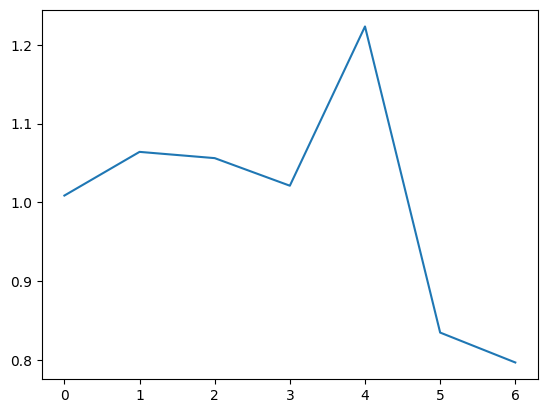

In [51]:
plt.plot(VI_scores.values())

The VI metric (and other metrics) can't be compared directly across aggregation levels.

# Reading

- Measures the distance between two partitions on the same dataset

Way to compare clusterings:
1) Comparing clusterings by counting pairs
This criteria is based on counting the number of pairs of points on which two clusterings agree/disagree.

The paper expresses the negatives of the adjusted Rand index and other metrics under this hood of counting pairs.

2) Comparing clusterings by set matching


**Variation of information**

$P(k) = \frac{n_k}{n}$

$H(C) = - \sum_{k=1}^K P(k)\log P(k)$

$H(C)$ is the entropy associated with clustering $C$. Entropy is non-negative, it takes value 0 when there is no uncertainty, when there is only one cluster.


Now define the mutual information between two clusterings, i.e the information that one clustering has about the other.

Denote $P(k), k = 1, \ldots , K$, $P'(k'), k' = 1, \ldots, K'$, then random varaibles associated with the clustering C, C'. 

Let $P(k,k')$ represent the probability that a point belongs to $C_k$ in clustering C and to $C_k'$ in $C'$, the joint distribution of the random variables associated with the two clusterings.

$P(k,k') = \frac{{|C_k \cap C_k'|}}{n}$


Define $I(C,C')$ the mutual information between the clustering C, C' to be equal to the mutual information between the associated random variables

$
I(C, C') = \sum_{k=1}^{K} \sum_{k'=1}^{K}
P(k,k') \log \left(
\frac{P(k,k')}{P(k)\,P(k')}
\right).
$

Can interpret $I(C,C')$ in the following way. We are given a random point, the uncertainty about its cluster in C' is measured by H(C'), suppose we are now told which cluster the point belongs to in C, how much does this knowledge reduce the uncertainty about C'. This reduction in uncertainty, averaged over al points, is equal to I(C,C').


The comparision criteria for two clusterings $C,C'$ is the quantity:

$VI(C,C') = H(C) + H(C') - 2I(C,C')$


Properties of VI:

- VI is a metric (distance) on clusterings
- VI(C,C') depends on relative sizes of clusters, not on number of points in the dataset
- $VI(C,C') \leq logn$
-  If $C$ and $C'$ have at most $K^*$ clusters each, with $K^* \ll \sqrt{n}$, then
$
\operatorname{VI}(C, C') \leq 2 \log K^*.
$
- Convex additivity and locality

Comparing VI with other criteria

- The Rand, adjusted Rand, Fowlkes–Mallows, Jaccard, and Wallace indices are asymptotically n-invariant in the limit of large n. For finite values of n the dependence on n is weak. It is also
non-linear, and we do not see a natural way of making these criteria exactly n-invariant.


The paper states the disadvantages of ARI and other metrics and why the properties of VI make it better in some contexts

https://www.sciencedirect.com/science/article/pii/S0047259X06002016